# Exploration Data Analys (EDA) 
Final Project CODA-021-RMT-Group 001

In [17]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## Import libraries

In [21]:
import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [19]:
# Baca file .env yang sama kayak yang dipakai Airflow (taruh notebook ini
# sejalur/tau lokasi file .env-nya, atau isi path lengkapnya ke load_dotenv())
load_dotenv()
 
CONNECTION_STRING = os.environ.get("NEON_CONNECTION_STRING")
engine = create_engine(CONNECTION_STRING)
 
# Baca tiap tabel Star Schema (nama kolom huruf kecil semua, jadi query-nya
# nggak perlu tanda kutip sama sekali)
fact_gaji_pekerjaan = pd.read_sql("SELECT * FROM fact_gaji_pekerjaan", con=engine)
dim_pekerjaan = pd.read_sql("SELECT * FROM dim_pekerjaan", con=engine)  # sudah termasuk kategori_pekerjaan
dim_perusahaan = pd.read_sql("SELECT * FROM dim_perusahaan", con=engine)
dim_lokasi = pd.read_sql("SELECT * FROM dim_lokasi", con=engine)
 
# Gabungin balik di Pandas - kategori_pekerjaan otomatis ikut kebawa lewat dim_pekerjaan
df = fact_gaji_pekerjaan.merge(dim_pekerjaan, on='id_pekerjaan', how='left')
df = df.merge(dim_perusahaan, on='id_perusahaan', how='left')
df = df.merge(dim_lokasi, on='id_lokasi', how='left')
 
df.head()

,id_gaji_pekerjaan,id_pekerjaan,id_perusahaan,id_lokasi,gaji_rata2,judul_pekerjaan,kategori_pekerjaan,perusahaan,lokasi
0,1,1,1,1,10500000,Senior Customer Service,Customer Service,PT Higienis Indonesia,Jakarta Raya
1,2,1,1,1,9221095,Senior Customer Service,Customer Service,PT Higienis Indonesia,Jakarta Raya
2,3,2,2,2,5409910,Management Trainee Store Kalimantan,Retail/Store,PT Richeese Kuliner Indonesia,Banjarmasin Selatan
3,4,3,3,3,10500000,Business Development Executive,Sales/Marketing,PT Arupa Cloud Nusantara,Jakarta Selatan
4,5,4,4,4,6000000,Content Creator,Live Streaming/Kreator Konten,PT Cahaya Ayu Abadi,Kecamatan Tangerang


In [20]:
# Melihat deskripsi data dari kolon gaji_rata2
df['gaji_rata2'].describe()

count    1.095600e+04
mean     7.346671e+06
std      4.076214e+06
min      1.000000e+06
25%      5.164812e+06
50%      6.179078e+06
75%      8.005069e+06
max      6.250000e+07
Name: gaji_rata2, dtype: float64

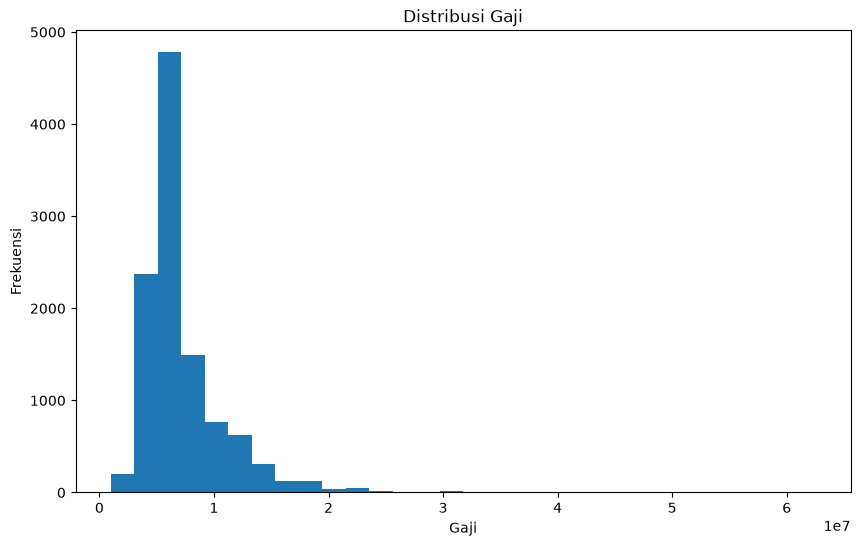

In [ ]:
# Membuat histogram distribusi gaji
plt.figure(figsize=(10, 6))

plt.hist(df['gaji_rata2'], bins=30)

plt.xlabel('Gaji')
plt.ylabel('Frekuensi')
plt.title('Distribusi Gaji')

plt.show()

C:\Users\Siti Sartika H\AppData\Local\Temp\ipykernel_34120\1406442872.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['gaji_rata2'], vert=False)


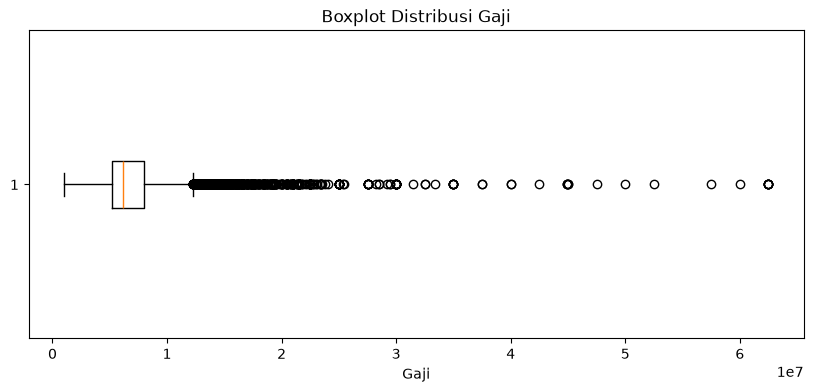

In [23]:
# Membuat boxplot distribusi gaji
plt.figure(figsize=(10, 4))

plt.boxplot(df['gaji_rata2'], vert=False)

plt.xlabel('Gaji')
plt.title('Boxplot Distribusi Gaji')

plt.show()

In [28]:
# Mengecek outlier menggunakan metode IQR
Q1 = df["gaji_rata2"].quantile(0.25)
Q3 = df["gaji_rata2"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["gaji_rata2"] < lower_bound) |
    (df["gaji_rata2"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Jumlah outlier:", len(outliers))

outliers

Q1: 5164812.25
Q3: 8005069.0
IQR: 2840256.75
Lower Bound: 904427.125
Upper Bound: 12265454.125
Jumlah outlier: 1048


,id_gaji_pekerjaan,id_pekerjaan,id_perusahaan,id_lokasi,gaji_rata2,judul_pekerjaan,kategori_pekerjaan,perusahaan,lokasi
76,77,72,72,20,14029577,Area Sales Manager (Sub. Distribution Timur),Manajerial/Eksekutif,PT Pangan Lestari,Sidoarjo
103,104,98,97,6,20500000,KEPALA DIVISI PENJUALAN,Manajerial/Eksekutif,Perumda Dharma Jaya,Jakarta Timur
104,105,99,98,34,16500000,Production Supervisor (Cutting Coil),Manajerial/Eksekutif,PT INTISUMBER BAJASAKTI,Cikande
121,122,116,114,36,12500000,Tattoo Shop Receptionist,Lainnya,Pengiklan Anonim,Bali
148,149,140,137,1,27500000,SENIOR SALES MANAGER,Manajerial/Eksekutif,PT Kahar Duta Sarana,Jakarta Raya
...,...,...,...,...,...,...,...,...,...
10899,10900,8639,852,1,18853120,Key Account Manager (Packaging and Bakery),Manajerial/Eksekutif,PT Royal Sutan Agung,Jakarta Raya
10917,10918,8654,137,205,15000000,BRANCH MANAGER SEMARANG,Manajerial/Eksekutif,PT Kahar Duta Sarana,Semarang Tengah
10926,10927,8662,4959,1,13111060,"Key Account Manager, Product Assembly Industry",Manajerial/Eksekutif,Nordson Advanced Technology Singapore,Jakarta Raya
10929,10930,8664,2038,48,12728256,HR&GA Manager,Manajerial/Eksekutif,PT anugerah megah lestari textile,Kabupaten Bandung


In [25]:
# Mengecek skewness dari distribusi gaji
print("Skewness:", df["gaji_rata2"].skew())

Skewness: 4.227062441448314


Insight :
Variabel gaji_rata2 memiliki nilai skewness sebesar 4,227, yang menunjukkan bahwa distribusi data sangat menceng ke kanan (positively skewed). Kondisi ini mengindikasikan adanya sejumlah observasi dengan nilai gaji yang jauh lebih tinggi dibandingkan mayoritas data. Oleh karena itu, penggunaan median sebagai ukuran tendensi sentral dapat membantu memberikan gambaran yang lebih representatif dibandingkan hanya menggunakan mean.

In [ ]:
# Pengecekan kembali nilai mean dan median untuk memastikan skewnessnya
df["gaji_rata2"].agg(["mean", "median", "min", "max"])

mean      7.346671e+06
median    6.179078e+06
min       1.000000e+06
max       6.250000e+07
Name: gaji_rata2, dtype: float64

Analisis Distribusi Gaji:

Variabel gaji_rata2 memiliki rata-rata sebesar Rp7,35 juta, sedangkan median sebesar Rp6,18 juta. Nilai rata-rata yang lebih tinggi dibandingkan median menunjukkan bahwa distribusi gaji cenderung menceng ke kanan. Hal ini konsisten dengan nilai skewness sebesar 4,227. Rentang gaji berada antara Rp1 juta hingga Rp62,5 juta, yang mengindikasikan adanya beberapa observasi dengan nilai gaji yang relatif tinggi dan berpotensi menjadi outlier.

In [26]:
# Mengecek distribusi pekerjaan berdasarkan kategori pekerjaan
df["kategori_pekerjaan"].value_counts().head(10)

kategori_pekerjaan
Manajerial/Eksekutif             3039
Sales/Marketing                  1976
Lainnya                          1717
Keuangan/Akuntansi                810
Engineering                       383
Administrasi/Sekretaris           373
IT/Digital                        342
Live Streaming/Kreator Konten     299
Perbankan/Asuransi                278
Produksi/QC/Manufaktur            253
Name: count, dtype: int64

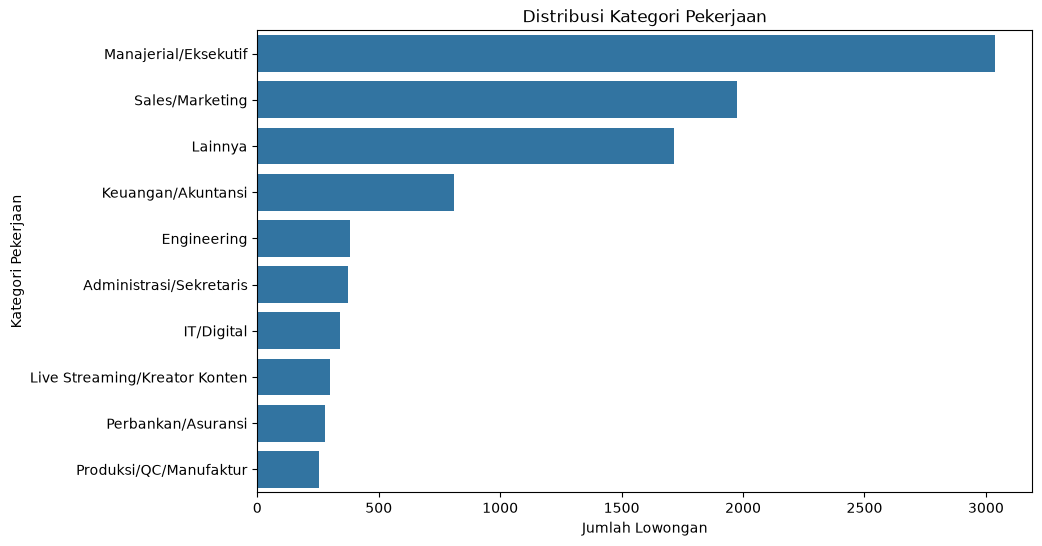

In [27]:
kategori = df["kategori_pekerjaan"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=kategori.values,
    y=kategori.index
)

plt.title("Distribusi Kategori Pekerjaan")
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Kategori Pekerjaan")

plt.show()

### KESIMPULAN EDA

1. Distribusi gaji → Right-skewed

2. Mean vs Median → Mean > Median

3. Skewness → 4,227

4. Outlier
   → Berdasarkan hasil analisis IQR menunjukkan adanya beberapa outlier pada variabel gaji_rata2. Outlier tersebut menunjukkan nilai gaji yang jauh lebih tinggi dibandingkan sebagian besar data. Karena nilai ekstrem tersebut belum tentu merupakan kesalahan data dan dapat merepresentasikan gaji pada posisi tertentu, outlier tetap dipertahankan untuk analisis selanjutnya.
   
5. Distribusi kategori pekerjaan → Distribusi kategori pekerjaan menunjukkan bahwa Manajerial/Eksekutif merupakan kategori dengan jumlah lowongan paling banyak sekitar 3.000 lowongan. Secara keseluruhan, distribusi lowongan tidak merata dan didominasi oleh beberapa kategori pekerjaan tertentu.
   
6. Kesimpulan umum → Data gaji memiliki distribusi tidak simetris dan perlu mempertimbangkan nilai ekstrem saat melakukan analisis perbandingan gaji.